In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [108]:
df = pd.read_csv("online_retail.csv")
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [109]:
print(df.info()) 
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   1

In [110]:
# REMOVE DUPLICATE ROWS
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped   : {before - len(df):,} duplicate rows")
print(f"Remaining : {len(df):,} rows")

Dropped   : 34,335 duplicate rows
Remaining : 1,033,036 rows


In [111]:
#  HANDLE MISSING VALUES
print("Missing before:")
print(df.isnull().sum())
 
df.dropna(subset=["Customer ID"], inplace=True)
print(f"\nDropped rows with missing Customer ID. Remaining: {len(df):,}")
 
df.dropna(subset=["Description"], inplace=True)
print(f"Dropped rows with missing Description.  Remaining: {len(df):,}")
 

Missing before:
Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

Dropped rows with missing Customer ID. Remaining: 797,885
Dropped rows with missing Description.  Remaining: 797,885


In [112]:
# FIX DATA TYPES
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print("InvoiceDate converted to datetime.")
 
df["Customer ID"] = df["Customer ID"].astype(str)
print("Customer ID converted to string (categorical key).")
 
print("\nDtypes after fix:")
print(df.dtypes)

InvoiceDate converted to datetime.
Customer ID converted to string (categorical key).

Dtypes after fix:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object


In [113]:
# REMOVE CANCELLATIONS
before = len(df)
df = df[~df["Invoice"].str.startswith("C")]
print(f"Dropped   : {before - len(df):,} cancellation rows (Invoice starts with 'C')")
print(f"Remaining : {len(df):,} rows")

Dropped   : 18,390 cancellation rows (Invoice starts with 'C')
Remaining : 779,495 rows


In [114]:
# REMOVE NEGATIVE / ZERO QUANTITIES AND PRICES
before = len(df)
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print(f"Dropped   : {before - len(df):,} rows with Quantity ≤ 0 or Price ≤ 0")
print(f"Remaining : {len(df):,} rows")

Dropped   : 70 rows with Quantity ≤ 0 or Price ≤ 0
Remaining : 779,425 rows


In [115]:
# STRIP WHITESPACE FROM STRING COLUMNS
str_cols = ["Description", "Country", "StockCode"]
for col in str_cols:
    df[col] = df[col].str.strip()
print(f"Stripped whitespace from: {str_cols}")


Stripped whitespace from: ['Description', 'Country', 'StockCode']


In [116]:
# performing the churn window split 

snapshot_date = df['InvoiceDate'].max()           
churn_window_start = snapshot_date - pd.Timedelta(days=90)        
                                                                            
features_df = df[df['InvoiceDate'] < churn_window_start].copy()            
label_df = df[df['InvoiceDate'] >= churn_window_start].copy()                       
                                                                            
print("Snapshot date:", snapshot_date)                                       
print("Churn window start:", churn_window_start)                             
print("Features df:", features_df.shape)        
print("Label df:", label_df.shape)

Snapshot date: 2011-12-09 12:50:00
Churn window start: 2011-09-10 12:50:00
Features df: (620572, 8)
Label df: (158853, 8)


In [117]:
# building the churn labels

active_customers = set(label_df['Customer ID'].unique())
all_customers = features_df['Customer ID'].unique()

churn_labels = pd.DataFrame({
    'Customer ID': all_customers,
    'Churn': (~pd.Series(all_customers).isin(active_customers)).astype(int)
})

print(churn_labels['Churn'].value_counts())

Churn
1    2989
0    2292
Name: count, dtype: int64


In [118]:
# RFM features from features_df

features_df['Revenue'] = features_df['Quantity'] * features_df['Price']

rfm = features_df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate', 'max'),
    Frequency = ('Invoice', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()

rfm['Recency'] = (snapshot_date - rfm['Recency']).dt.days

print(rfm.shape)
print(rfm.head())

(5281, 4)
  Customer ID  Recency  Frequency  Monetary
0     12346.0      325         12  77556.46
1     12347.0      129          6   3402.39
2     12348.0      248          4   1709.40
3     12349.0      407          3   2671.14
4     12350.0      309          1    334.40


In [119]:
# additional features plus merge to the churn table

rfm['avg_basket_size'] = rfm['Monetary'] / rfm['Frequency']                                                                                                    
                                                                                                                                                                 
is_uk = features_df.groupby('Customer ID')['Country'].first().reset_index()                                                                                    
is_uk['is_uk'] = (is_uk['Country'] == 'United Kingdom').astype(int)                                                                                            
                                                                        
rfm = rfm.merge(is_uk[['Customer ID', 'is_uk']], on='Customer ID')                                                                                             
rfm = rfm.merge(churn_labels, on='Customer ID')

print(rfm.shape)
print(rfm.head())

(5281, 7)
  Customer ID  Recency  Frequency  Monetary  avg_basket_size  is_uk  Churn
0     12346.0      325         12  77556.46      6463.038333      1      1
1     12347.0      129          6   3402.39       567.065000      0      0
2     12348.0      248          4   1709.40       427.350000      0      0
3     12349.0      407          3   2671.14       890.380000      0      0
4     12350.0      309          1    334.40       334.400000      0      1


In [120]:
# null check and outliers

print(rfm.isnull().sum())                                                                                                                                      
print(rfm.describe())

Customer ID        0
Recency            0
Frequency          0
Monetary           0
avg_basket_size    0
is_uk              0
Churn              0
dtype: int64
           Recency    Frequency       Monetary  avg_basket_size        is_uk  \
count  5281.000000  5281.000000    5281.000000      5281.000000  5281.000000   
mean    297.282901     5.745692    2637.863286       369.292417     0.911380   
std     175.007174    11.464582   12225.544955       538.206215     0.284221   
min      90.000000     1.000000       2.900000         2.900000     0.000000   
25%     139.000000     1.000000     318.240000       174.668000     1.000000   
50%     254.000000     3.000000     783.580000       276.860000     1.000000   
75%     416.000000     6.000000    2078.540000       409.725000     1.000000   
max     738.000000   309.000000  456780.490000     14844.766667     1.000000   

             Churn  
count  5281.000000  
mean      0.565991  
std       0.495673  
min       0.000000  
25%       0.00

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [122]:
X = rfm.drop(columns=['Customer ID', 'Churn'])
y = rfm['Churn']

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y                                                                                                           
)

In [124]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
print("Train size:", X_train.shape)                                      
print("Test size:", X_test.shape)

Train size: (4224, 5)
Test size: (1057, 5)


In [126]:
from sklearn.ensemble import RandomForestClassifier      
from sklearn.metrics import classification_report, confusion_matrix                                                                                            
                                                                                                                                                                
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)                                                                      
rf.fit(X_train_scaled, y_train)                                                                                                                                
                                                        
y_pred = rf.predict(X_test_scaled)                                                                                                                             
                                            
print(confusion_matrix(y_test, y_pred))                                                                                                                        
print(classification_report(y_test, y_pred))

[[287 172]
 [142 456]]
              precision    recall  f1-score   support

           0       0.67      0.63      0.65       459
           1       0.73      0.76      0.74       598

    accuracy                           0.70      1057
   macro avg       0.70      0.69      0.70      1057
weighted avg       0.70      0.70      0.70      1057



Precision = TP / (TP + FP)                                                                                                                                     
  Recall    = TP / (TP + FN)                                               
  F1        = 2 × (Precision × Recall) / (Precision + Recall)                                                                                                    
  Accuracy  = (TP + TN) / (TP + TN + FP + FN)

In [127]:
precision = 456/(172+456)
recall = 456/(456+142)
f1 = 2 * (precision*recall)/(precision+recall)
accuracy = (456+287)/(287+172+142+456)

print("Precision: ", precision)
print("Recall: ", recall)
print("F1 score: ",f1)
print("Accuracy: ",accuracy)

Precision:  0.7261146496815286
Recall:  0.7625418060200669
F1 score:  0.7438825448613378
Accuracy:  0.7029328287606433


In [128]:
# plotting the roc-auc score and pr score 

from sklearn.metrics import roc_auc_score, average_precision_score


In [129]:
y_proba_pos = rf.predict_proba(X_test_scaled)[:,1]

roc_score = roc_auc_score(y_test, y_proba_pos)

pr_score = average_precision_score(y_test, y_proba_pos)

In [130]:
print(f"ROC-AUC: {roc_score:.4f}")
print(f"PR-AUC: {pr_score:.4f}")

ROC-AUC: 0.7615
PR-AUC: 0.7761


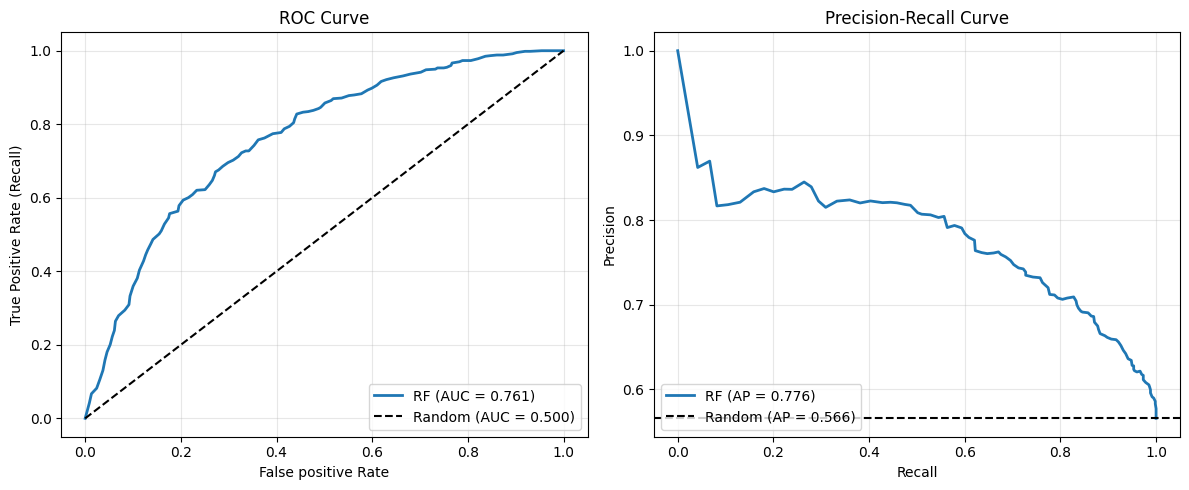

In [131]:
from sklearn.metrics import roc_curve, precision_recall_curve

# these provides the arrays to plot directly
# curve data

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_pos)

prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba_pos)

# random basline for PR curve = base rate of positive class in y_test
base_rate = y_test.mean()

fig, axes = plt.subplots(1,2, figsize=(12,5))

# axes[0] is left subplot, axes[1] is right
# ---- ROC curve (left) ----
axes[0].plot(fpr, tpr, label=f"RF (AUC = {roc_score:.3f})", linewidth=2)
axes[0].plot([0,1], [0,1], "k--", label="Random (AUC = 0.500)")
axes[0].set_xlabel("False positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# ---- PR curve (right) ----
axes[1].plot(rec, prec, label=f"RF (AP = {pr_score:.3f})", linewidth=2)
axes[1].axhline(base_rate, linestyle="--", color="k", label=f"Random (AP = {base_rate:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Save
import os
os.makedirs("artifacts/plots", exist_ok=True)
plt.savefig("artifacts/plots/rf_roc_pr_curves.png", dpi = 120, bbox_inches="tight")
plt.show()

In [132]:
import numpy as np

target_recall = 0.85

# boolean mask 

mask = rec[:-1] >= target_recall

# get all indices,

valid_indices = np.where(mask)[0]

#  take the last index 

last_idx = valid_indices[-1]

In [133]:
# now reading everything

chosen_threshold = pr_thresholds[last_idx]

achieved_recall = rec[last_idx]

achieved_precision = prec[last_idx]

In [134]:
print(f"Chosen threshold: {chosen_threshold:.4f}")
print(f"Achieved recall: {achieved_recall:.4f}")
print(f"Achieved precision: {achieved_precision:.4f}")
print(f"Baseline (thr=0.5): recall=0.7625, precision=0.7261")

Chosen threshold: 0.3800
Achieved recall: 0.8579
Achieved precision: 0.6904
Baseline (thr=0.5): recall=0.7625, precision=0.7261


In [135]:
# threshold sweep table 

thresholds = [0.1,0.2,0.3,0.35, 0.38,0.4, 0.5, 0.7, 0.9]

rows = []

for t in thresholds:
    y_pred = (y_proba_pos >= t).astype(int)

    cm_base = confusion_matrix(y_test, y_pred)
    TN,FP,FN,TP = cm_base.ravel()

    if TP + FP == 0:
        precision = 0

    precision = TP/ (TP+FP)
    

    if TP + FN == 0:
        recall = 0

    recall = TP/ (TP+FN)
    

    if precision + recall == 0:
        f1 = 0

    f1 = 2*precision*recall/(precision + recall)

    if TP+FP+TN+FN == 0:
        accuracy = 0
    
    accuracy = (TP + TN) / (TP+TN+FP+FN)

    rows.append({"threshold": t, "TP": TP, "FP": FP, "FN": FN, "TN": TN, "precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy})

thr_df = pd.DataFrame(rows)

print(thr_df)

   threshold   TP   FP   FN   TN  precision    recall        f1  accuracy
0       0.10  589  384    9   75   0.605344  0.984950  0.749841  0.628193
1       0.20  568  336   30  123   0.628319  0.949833  0.756325  0.653737
2       0.30  537  275   61  184   0.661330  0.897993  0.761702  0.682119
3       0.35  521  246   77  213   0.679270  0.871237  0.763370  0.694418
4       0.38  513  230   85  229   0.690444  0.857860  0.765101  0.701987
5       0.40  504  224   94  235   0.692308  0.842809  0.760181  0.699149
6       0.50  463  180  135  279   0.720062  0.774247  0.746172  0.701987
7       0.70  355   94  243  365   0.790646  0.593645  0.678128  0.681173
8       0.90  158   29  440  430   0.844920  0.264214  0.402548  0.556291


In [136]:
# generating the predictions at chosen threshold

y_pred_tuned = (y_proba_pos >= chosen_threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned) # tuned matrix

TN,FP,FN,TP = cm_tuned.ravel()

if TP + FP == 0:
    tuned_precision = 0

tuned_precision = TP/ (TP+FP)
    

if TP + FN == 0:
    tuned_recall = 0

tuned_recall = TP/ (TP+FN)
    

if tuned_precision + tuned_recall == 0:
    tuned_f1 = 0

tuned_f1 = 2*tuned_precision*tuned_recall/(tuned_precision + tuned_recall)

if TP+FP+TN+FN == 0:
    tuned_accuracy = 0

tuned_accuracy = (TP + TN)/ (TP+FP+TN+FN)



In [137]:
print(f"Tuned precision: {tuned_precision:.4f}")
print(f"Tuned recall: {tuned_recall:.4f}")
print(f"Tuned f1: {tuned_f1:.4f}")
print(f"Tuned Accuracy: {tuned_accuracy:.4f}")

Tuned precision: 0.6904
Tuned recall: 0.8579
Tuned f1: 0.7651
Tuned Accuracy: 0.7020


In [138]:
default_recall_sweep = thr_df.loc[thr_df['threshold'] == 0.5, 'recall'].values[0]
default_precision_sweep = thr_df.loc[thr_df['threshold'] == 0.5, 'precision'].values[0]

recall_lift = tuned_recall - default_recall_sweep
precision_lift = tuned_precision - default_precision_sweep

print(f"Recall lift: {recall_lift}")
print(f"Precision lift: {precision_lift}")

Recall lift: 0.08361204013377921
Precision lift: -0.02961806304147152


## Threshold Decision — Project 3                                            
                                                                               
  After plotting the precision-recall curve and sweeping thresholds, we chose
  **threshold = 0.38** for production predictions.                             
                  
  ### Selection criterion                                                      
  Highest threshold that still achieves **recall ≥ 0.85** on the test set.
                                                                               
  ### Why bias toward recall                                                   
  Missing a churning customer = lost recurring revenue. Falsely flagging a
  loyal customer = a marginal-cost retention email. Therefore the business cost
   of FN >> cost of FP, so we tune toward recall.
                                                                               
  ### Comparison — baseline (0.50) vs tuned (0.38)                             
   
  | Metric    | Baseline (0.50) | Tuned (0.38) | Lift     |                    
  |-----------|-----------------|--------------|----------|
  | Recall    | 0.7742          | 0.8579       | +8.4 pp  |                    
  | Precision | 0.7201          | 0.6904       | −3.0 pp  |
  | F1        | 0.7462          | 0.7651       | +1.9 pp  |                    
  | Accuracy  | 0.7020          | 0.7020       |  0.0 pp  |
                                                                               
  ### Confusion matrix (test set, n = 1057)
                                                                               
  | Threshold      | TP  | FP  | FN  | TN  |                                   
  |----------------|-----|-----|-----|-----|
  | 0.50 baseline  | 463 | 180 | 135 | 279 |                                   
  | 0.38 tuned     | 513 | 230 |  85 | 229 |                                   
   
  **Customer-level reading:** 50 more churners caught, 50 more false alarms —  
  ~1:1 trade. F1 went up because the default 0.5 wasn't F1-optimal on this
  model.                                                                       
                  
  ### To wire into the pipeline (Project 3 Week 4 Day 3)                       
  - `training_pipeline.py` will:
    - Train RF on training set                                                 
    - Compute precision-recall curve on test set                               
    - Pick threshold using the same criterion (recall ≥ 0.85)
    - Save threshold to `artifacts/metrics/chosen_threshold.json`              
    - Co-save model + scaler + threshold so the prediction pipeline loads a    
  consistent set                                                               
  - `prediction_pipeline.py` will:                                             
    - Load model, scaler, threshold                                            
    - Apply `(model.predict_proba(X)[:, 1] >= threshold).astype(int)`

In [139]:
# side-by-side comparison: baseline (rf.predict) vs tuned                    
# (threshold=chosen_threshold)                                                 

print("=" * 70)                                                              
print("BASELINE — threshold = 0.50 (sklearn default via rf.predict)")
print("=" * 70)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))                                      
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))                       
                
# tuned predictions at the chosen threshold                                  
y_pred_tuned = (y_proba_pos >= chosen_threshold).astype(int)
                                                                            
print("=" * 70) 
print(f"TUNED — threshold = {chosen_threshold:.4f}")
print("=" * 70)                                                              
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_tuned))                                
print("\nClassification report:")                                            
print(classification_report(y_test, y_pred_tuned, digits=4))
                                                                            
print("=" * 70) 
print("LIFT SUMMARY (positive class = churn)")
print("=" * 70)                                                              
print(f"Recall:   {default_recall_sweep:.4f} → {achieved_recall:.4f}   (Δ {recall_lift:+.4f})")                                                        
print(f"Precision: {default_precision_sweep:.4f} → {achieved_precision:.4f}(Δ {precision_lift:+.4f})")

BASELINE — threshold = 0.50 (sklearn default via rf.predict)

Confusion matrix:
[[430  29]
 [440 158]]

Classification report:
              precision    recall  f1-score   support

           0     0.4943    0.9368    0.6471       459
           1     0.8449    0.2642    0.4025       598

    accuracy                         0.5563      1057
   macro avg     0.6696    0.6005    0.5248      1057
weighted avg     0.6926    0.5563    0.5087      1057

TUNED — threshold = 0.3800

Confusion matrix:
[[229 230]
 [ 85 513]]

Classification report:
              precision    recall  f1-score   support

           0     0.7293    0.4989    0.5925       459
           1     0.6904    0.8579    0.7651       598

    accuracy                         0.7020      1057
   macro avg     0.7099    0.6784    0.6788      1057
weighted avg     0.7073    0.7020    0.6901      1057

LIFT SUMMARY (positive class = churn)
Recall:   0.7742 → 0.8579   (Δ +0.0836)
Precision: 0.7201 → 0.6904(Δ -0.0296)


In [140]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [141]:
# selecting rfm features into X_rfm

X_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

In [142]:
# scale the features

scaler = StandardScaler()

X_rfm_scaled = scaler.fit_transform(X_rfm)

In [143]:
# fit K-Means

km = KMeans(n_clusters=3, random_state=42, n_init=10)

km.fit(X_rfm_scaled)

/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: Runt

KMeans(n_clusters=3, n_init=10, random_state=42)

In [144]:
# attach cluster labels to original dataframe

rfm['cluster'] = km.labels_

In [145]:
# summarizing each cluster

cluster_summary = rfm.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print(cluster_summary)

            Recency   Frequency       Monetary
cluster                                       
0        169.058303    7.465444    3031.406725
1        476.429995    2.217490     772.225761
2        111.190476  126.523810  141493.763333


In [146]:
# print the inertia

print(f"inertia (k=3): {km.inertia_:.2f}")

inertia (k=3): 6493.96


In [147]:
# cluster sizes

rfm['cluster'].value_counts()

cluster
0    3053
1    2207
2      21
Name: count, dtype: int64

In [152]:

# elbow method

# initialize an empty list for inertia

inertias = []

k_range = range(2,9)

for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)

    km_elbow.fit(X_rfm_scaled)

    inertias.append(km_elbow.inertia_)




/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: Runt

In [153]:
for i in inertias:
    print(i, "\n")

10758.399412429018 

6493.957026641019 

4655.800377192054 

3538.7449821485243 

2803.9628584435673 

2276.423595810357 

1961.2018170903839 



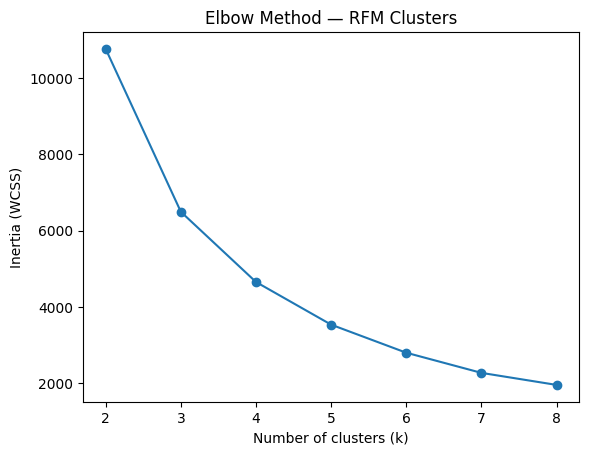

In [ ]:
# plotting the elbow

import matplotlib.pyplot as plt             
                                                                             
plt.plot(k_range, inertias, marker='o')                                      
plt.xlabel('Number of clusters (k)')                    
plt.ylabel('Inertia (WCSS)')                                                 
plt.title('Elbow Method — RFM Clusters')                                   

# Save
import os
os.makedirs("artifacts/plots", exist_ok=True)
plt.savefig("artifacts/plots/elbow_curve.png", dpi = 120, bbox_inches="tight")
plt.show()

finding — Elbow at k=3                                           
                                                                               
  | k | Inertia | Drop | % drop |                                            
  |---|---|---|---|                       
  | 2 | 10,758.40 | — | — |                                                    
  | **3** | **6,493.96** | **−4,264.44** | **−39.6%** |   
  | 4 | 4,655.80 | −1,838.16 | −28.3% |                                        
  | 5 | 3,538.74 | −1,117.06 | −24.0% |                                      
  | 6 | 2,803.96 | −734.78 | −20.8% |                     
  | 7 | 2,276.42 | −527.54 | −18.8% |                                          
  | 8 | 1,961.20 | −315.22 | −13.8% |                     
                                                                               
  The k=2→k=3 drop is **2.3× the next-biggest drop** — clear elbow at k=3.     
                                                
  **Caveat:** the elbow is driven by 21 B2B/wholesale customers becoming their 
  own cluster.                                                                 
  If those were stripped as outliers first, the elbow would likely shift to k=2
   (regulars vs lapsed).                                                       
  Day 3 (DBSCAN) will give that alternative view by tagging the 21 as noise    
  (-1).